In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler,LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from  sklearn.cluster import KMeans,MiniBatchKMeans,AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,davies_bouldin_score
import hdbscan
from sklearn.decomposition import PCA

In [2]:
data=pd.read_csv("dataset_spotif.csv", sep=",")
print(data.columns)
print(data.head())

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
data.isna().sum()[data.isna().sum()>0]

artists       1
album_name    1
track_name    1
dtype: int64

In [6]:
data=data.dropna(subset=["artists", "album_name", "track_name"])

print("shape after drop : ",data.shape)

shape after drop :  (113999, 21)


In [7]:
data = data.drop(columns=["Unnamed: 0"])
print("dupliquate in track id : ",data["track_id"].duplicated().sum())
data=data.drop_duplicates(subset="track_id", keep="first").copy()
print("demention after delete dupliquate music track and unamed col (col of index )",data.shape)

dupliquate in track id :  24259
demention after delete dupliquate music track and unamed col (col of index ) (89740, 20)


In [8]:
num_col=[col for col in data.columns if data[col].dtype == "int64" or data[col].dtype == "float64"]
categ_col=[col for col in data.columns if data[col].dtype == "object"]

In [9]:
three_shold=3
for col in num_col:
   z_score=np.abs(stats.zscore(data[col]))
   ouliers=data[z_score>three_shold]
   print("outliers in col {} : {}".format(col,len(ouliers)/data.shape[0]))

outliers in col popularity : 0.00012257633162469355
outliers in col duration_ms : 0.008156897704479608
outliers in col danceability : 0.0017494985513706262
outliers in col energy : 0.0
outliers in col key : 0.0
outliers in col loudness : 0.0219188767550702
outliers in col mode : 0.0
outliers in col speechiness : 0.018197013594829507
outliers in col acousticness : 0.0
outliers in col instrumentalness : 0.0
outliers in col liveness : 0.03182527301092044
outliers in col valence : 0.0
outliers in col tempo : 0.0020726543347448184
outliers in col time_signature : 0.011232449297971918


In [10]:
print("nombre of genre",data["track_genre"].nunique())
print("nobre of artist",data["artists"].nunique())
print("nb of artist par genre : {}".format(round(data["artists"].nunique()/data["track_genre"].nunique(),2)))


nombre of genre 113
nobre of artist 31437
nb of artist par genre : 278.2


In [34]:
sns.reset_orig()

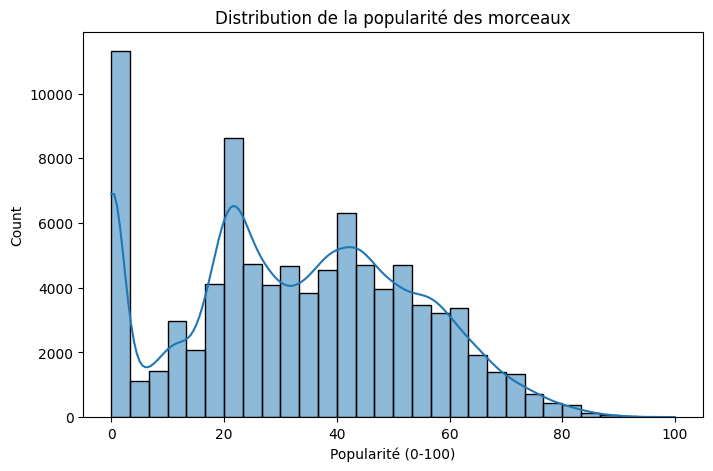

In [35]:

plt.figure(figsize=(8,5))
sns.histplot(data["popularity"],bins=30,kde=True)
plt.title("Distribution de la popularité des morceaux")
plt.xlabel("Popularité (0-100)")
plt.show()

In [36]:
genre_popul=data.groupby(["track_genre"])["popularity"].mean().sort_values(ascending=False).head(15)
print(genre_popul)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_popul.values,y=genre_popul.index,hue=genre_popul.index, palette="viridis", legend=False)
plt.xlabel("popularity moy")

track_genre
k-pop                59.423581
pop-film             59.096933
metal                56.422414
chill                53.738683
latino               51.788945
sad                  51.109929
grunge               50.587007
indian               49.765348
anime                48.776884
emo                  48.500000
reggaeton            48.270270
sertanejo            47.860775
piano                46.608312
progressive-house    46.537748
hard-rock            45.744711
Name: popularity, dtype: float64


Text(0.5, 0, 'popularity moy')

artists
Olivia Rodrigo    87.400000
Bad Bunny         85.363636
Lil Nas X         83.200000
One Direction     83.000000
Måneskin          82.600000
Name: popularity, dtype: float64


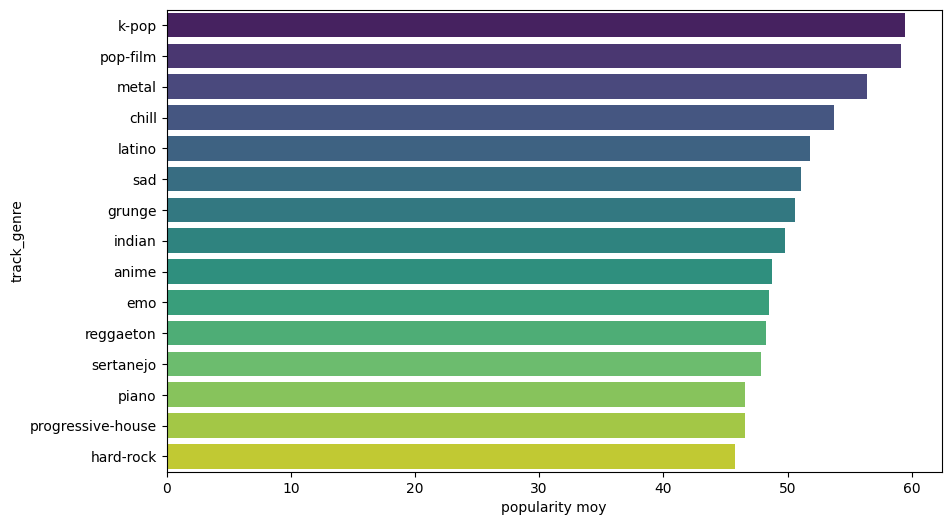

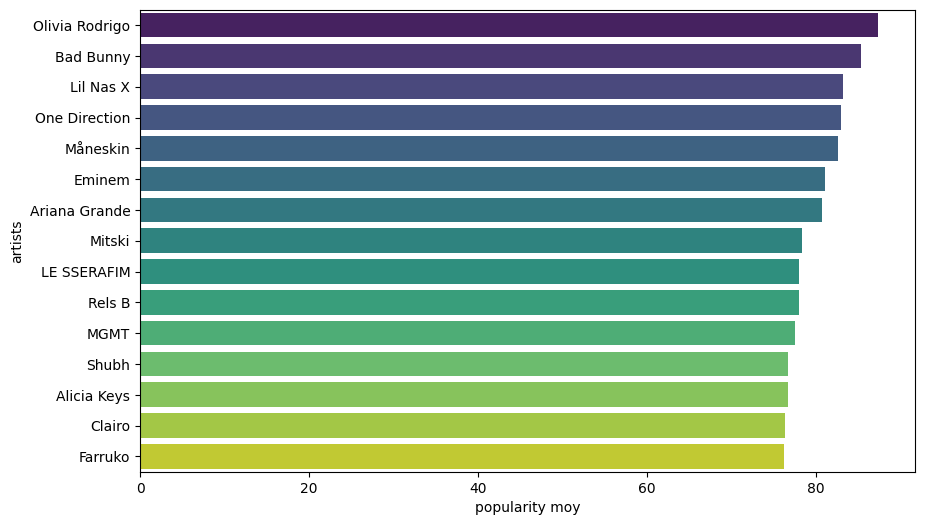

In [37]:
artist_count=data["artists"].value_counts()
principale_art=artist_count[artist_count>3].index

top_artist=(data[data["artists"].isin(principale_art)].groupby("artists")["popularity"].mean().sort_values(ascending=False).head(15))
print(top_artist.head())
plt.figure(figsize=(10,6))
sns.barplot(x=top_artist.values,y=top_artist.index,hue=top_artist.index,palette="viridis", legend=False)
plt.xlabel("popularity moy")
plt.show()

In [15]:
audio_feature = ["danceability", "energy", "valence", "acousticness", "speechiness", "tempo"]
top_genre=genre_popul.head(10).index
print(top_genre)
genre_porc=data[data["track_genre"].isin(top_genre)].groupby("track_genre")[audio_feature].mean()
print(genre_porc)

Index(['k-pop', 'pop-film', 'metal', 'chill', 'latino', 'sad', 'grunge',
       'indian', 'anime', 'emo'],
      dtype='object', name='track_genre')
             danceability    energy   valence  acousticness  speechiness  \
track_genre                                                                
anime            0.537666  0.674229  0.434644      0.267117     0.087429   
chill            0.666423  0.429531  0.408306      0.530572     0.103493   
emo              0.601147  0.667745  0.441194      0.191794     0.112685   
grunge           0.455414  0.804870  0.400566      0.047791     0.061500   
indian           0.585930  0.554673  0.448285      0.511175     0.068742   
k-pop            0.641783  0.682796  0.568961      0.294774     0.085454   
latino           0.755487  0.712343  0.622474      0.208931     0.121987   
metal            0.481177  0.841392  0.424929      0.035705     0.077117   
pop-film         0.591431  0.599897  0.528520      0.450419     0.062044   
sad            

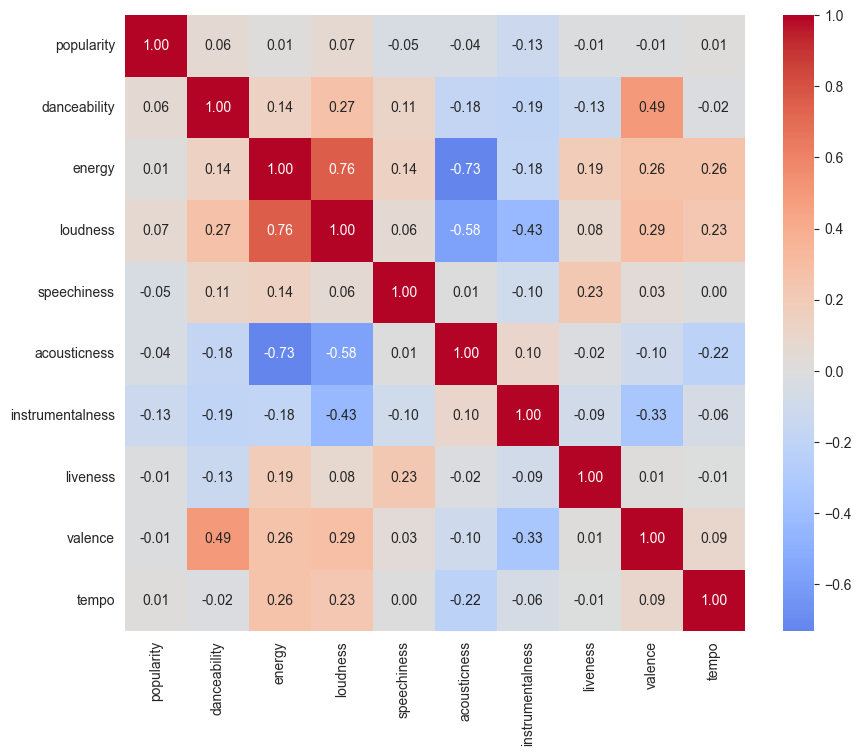

In [16]:
corr_features = ["popularity","danceability","energy","loudness","speechiness",
                  "acousticness","instrumentalness","liveness","valence","tempo"]
plt.figure(figsize=(10,8))
sns.heatmap(data[corr_features].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.show()

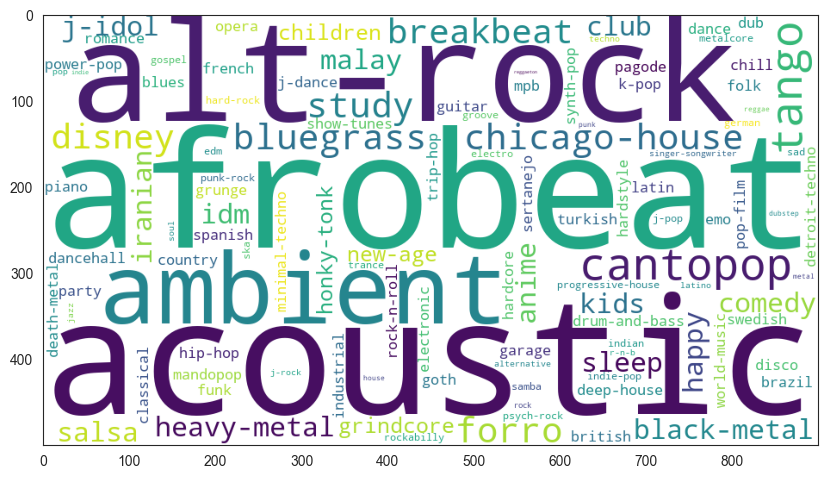

In [17]:
genre_fr = data["track_genre"].value_counts().to_dict()

wc_genre = WordCloud(width=900, height=500,background_color="white",colormap="viridis").generate_from_frequencies(genre_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_genre)
plt.show()

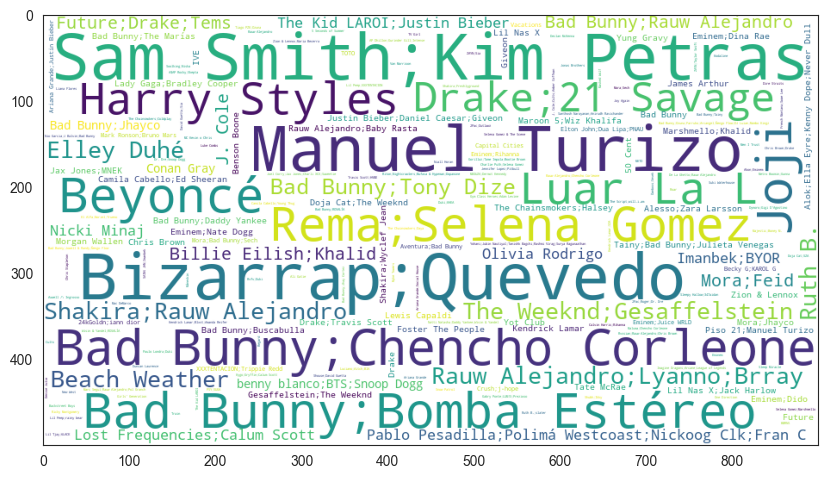

In [18]:
artist_fr=data.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(200).to_dict()
wc_artist = WordCloud(width=900, height=500, background_color="white",
                       colormap="viridis").generate_from_frequencies(artist_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_artist)
plt.show()

In [19]:
fut_princ=["danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness","valence", "tempo"]
princ_data=data[fut_princ].copy()
print(princ_data.head())
scaler=StandardScaler()
princ_data=scaler.fit_transform(princ_data)


   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  liveness  valence    tempo  
0          0.000001    0.3580    0.715   87.917  
1          0.000006    0.1010    0.267   77.489  
2          0.000000    0.1170    0.120   76.332  
3          0.000071    0.1320    0.143  181.740  
4          0.000000    0.0829    0.167  119.949  


In [20]:
inertie=[]
for k in range(2,12):
    km=KMeans(n_clusters=k,random_state=42, n_init=10)
    km.fit(princ_data)
    inertie.append(km.inertia_)
print(inertie)

[632735.1509039698, 561695.8865977827, 505597.7698733761, 455891.09955507726, 414345.85700588784, 377050.47469507065, 356486.11193784093, 337943.594654201, 324164.5503731923, 312026.396482687]


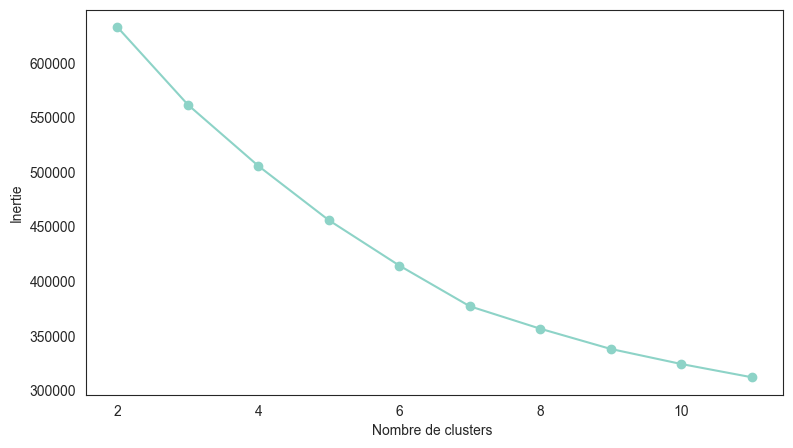

In [21]:
plt.figure(figsize=(9,5))
plt.plot(list(range(2,12)), inertie, marker="o")
plt.xlabel("Nombre de clusters ")
plt.ylabel("Inertie")
plt.show()

In [22]:
part_indx = np.random.RandomState(42).choice(len(princ_data), size=5000, replace=False)
part_data = princ_data[part_indx]
print(princ_data.shape)
print(part_data.shape)

(89740, 9)
(5000, 9)


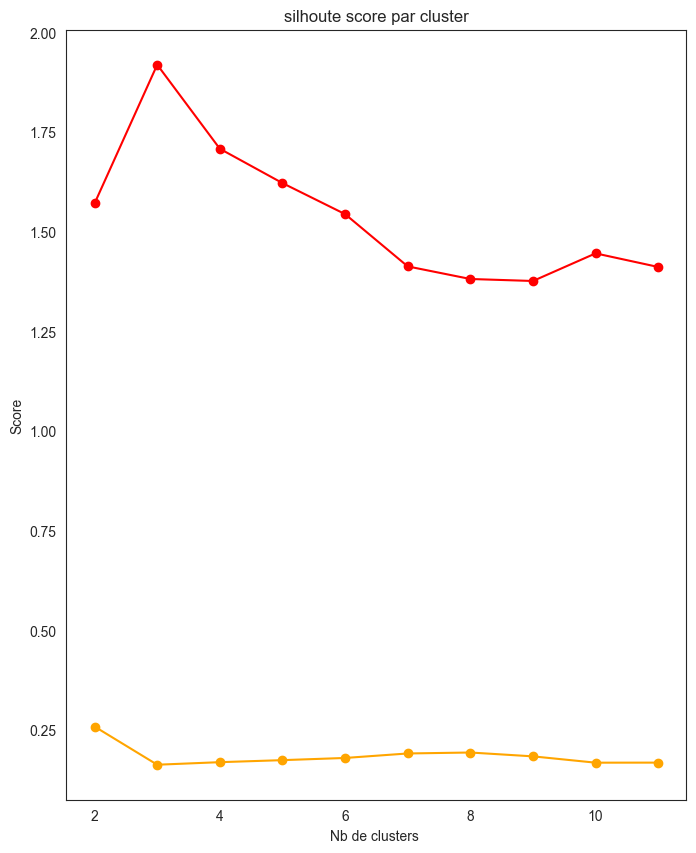

In [23]:
sil_scores = []
DVB=[]
for k in range(2,12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,10))
plt.plot(list(range(2,12)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,12)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster")
plt.show()

In [24]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : 0.19377881759751955
DVB de k=8 :  1.381610014154722


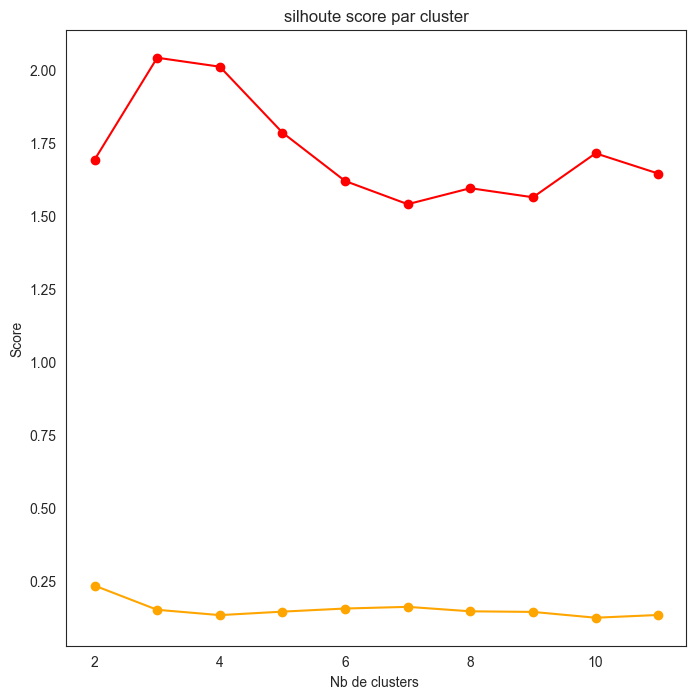

In [25]:
sil_scores = []
DVB=[]
for k in range(2,12):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=500)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,12)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,12)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster")
plt.show()

In [26]:
print("silhoutte de k=8 :", sil_scores[6])
print("DVB de k=8 : ", DVB[6])

silhoutte de k=8 : 0.14608332453835046
DVB de k=8 :  1.5943200341048107


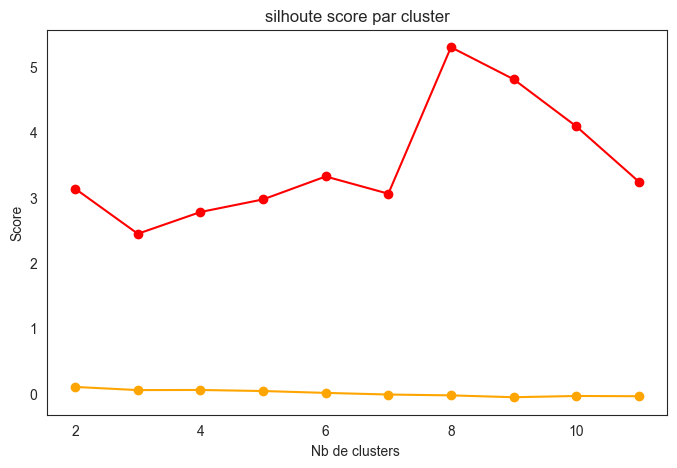

In [27]:
sil_scores = []
DVB=[]
for k in range(2,12):
    Gm = GaussianMixture( n_components=k,covariance_type='full',random_state=42)
    pred = Gm.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))

plt.figure(figsize=(8,5))
plt.plot(list(range(2,12)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,12)), DVB, marker="o", color="red")

plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster")
plt.show()

In [28]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : -0.025992487819533436
DVB de k=8 :  5.298717029507853


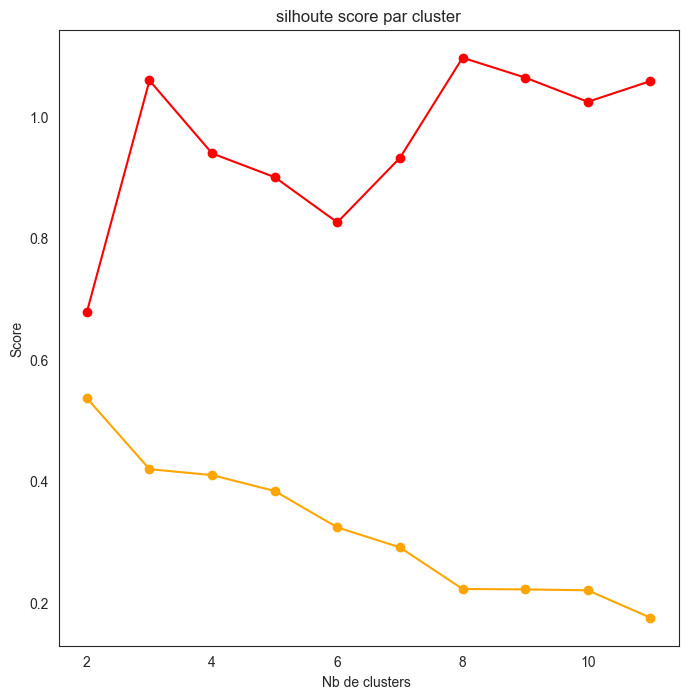

In [29]:
sil_scores = []
DVB=[]
for k in range(2,12):
    agg = AgglomerativeClustering(n_clusters=k, linkage='average')
    pred = agg.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,12)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,12)),DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster")
plt.show()

In [30]:
print("silhoutte de k=8 :",sil_scores[4])
print("DVB de k=8 : ",DVB[4])

silhoutte de k=8 : 0.3234089840081172
DVB de k=8 :  0.8256718840588556


In [31]:
sil_scores = []
DVB=[]
model = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
pred = model.fit_predict(part_data)
sil_scores.append(silhouette_score(part_data, pred))
DVB.append(davies_bouldin_score(part_data, pred))
print("silhoutte de k=8 :",sil_scores[0])
print("DVB de k=8 : ",DVB[0])

silhoutte de k=8 : 0.12757594444732376
DVB de k=8 :  2.764246757133422


In [32]:
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both

In [33]:
# k_agg=6
# pred=[]
# pred_agg=pd.DataFrame(pred)
# agg_model = AgglomerativeClustering(n_clusters=k_agg, linkage='average')
# pred_agg["cluster"]=agg_model.fit_predict(princ_data)
# print(pred_agg.value_counts().sort_values(ascending=False))


# i can't use this model !!!!!!!!!!!!!!!!!!!!! cause of memory

MemoryError: Unable to allocate 3.75 GiB for an array with shape (4026588930,) and data type bool

In [ ]:
k_KM=8
pred=[]
pred=pd.DataFrame(pred)
km_model=KMeans(n_clusters=k_KM,random_state=42,n_init=10)
pred["cluster"]=km_model.fit_predict(princ_data)
data["cluster"]=pred["cluster"]
print(pred.value_counts().sort_values(ascending=False))

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(princ_data)

data["pca_1"] = X_pca[:, 0]
data["pca_2"] = X_pca[:, 1]
print(data.columns)
plt.figure(figsize=(10,7))
sns.scatterplot(data=data, x="pca_1", y="pca_2", hue="cluster",
                 palette="tab10", s=15, alpha=0.6)
plt.title(f"Visualisation des clusters k={k_KM}")
plt.show()

print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum():.2%}")

In [ ]:
# DBSCAN
# Hierarchical clustering